# Ley de Malus cuántica para polarización elíptica
## Valores medios, estadística de fotones y funciones de Wigner

**Objetivo.** En `Malus_Generalizada.ipynb` dedujimos la ley de Malus generalizada clásica
$$C_{12}(\alpha_{\text{in}},\chi_{\text{in}},\alpha_P,\chi_P)=\tfrac12\big[1+\cos 2\chi_{\text{in}}\cos 2\chi_P\cos 2\phi+\sin 2\chi_{\text{in}}\sin 2\chi_P\big],\qquad \phi=\alpha_{\text{in}}-\alpha_P,$$
y su extensión a luz parcialmente polarizada, $I/S_0=\tfrac12(1+P\,\hat s_{\text{in}}\cdot\hat p)$. Aquí respondemos con rigor tres preguntas:

1. **¿Es cierto que llevar esta ley a cubits de polarización "sólo vale para estados coherentes"?**
   Veremos que la suposición es **incorrecta tal como está planteada**, pero contiene un núcleo de verdad que se puede enunciar con precisión (§2–§3).
2. **¿Cuál es la ley de Malus cuántica exacta para *cualquier* estado del campo, clásico o cuántico?**
   La construimos en tres niveles: valores medios (**Teorema 1**, §2), espacio de fases de variables continuas (**Teorema 2**, §4) y esfera de Poincaré (**Teorema 3**, §5).
3. **¿Sirve la función de Wigner para obtenerla?** Sí, de dos maneras complementarias: la función de Wigner de dos modos $W(\alpha_H,\alpha_V)$ y la función de Wigner de Stratonovich–Weyl para SU(2), $W(\Omega)$, definida directamente **sobre la esfera de Poincaré**.

**Resultados principales** (cada uno demostrado analíticamente y verificado numéricamente a precisión de máquina):

$$\textbf{T1:}\quad \hat b^{\dagger}\hat b=\tfrac12\big(\hat S_0+\hat p\cdot\hat{\vec S}\big)
\;\Longrightarrow\;
\frac{\langle \hat n_{\text{out}}\rangle}{\langle \hat S_0\rangle}=\tfrac12\big(1+P_Q\,\hat s\cdot\hat p\big)\quad\text{para TODO estado }\rho.$$

$$\textbf{T2:}\quad \langle \hat n_{\text{out}}\rangle=\int d^4\alpha\; W(\alpha_H,\alpha_V)\, I^{\text{Malus}}_{\text{clásica}}(\alpha;\alpha_P,\chi_P)\;-\;\tfrac12 .$$

$$\textbf{T3:}\quad p(k\ \text{transmitidos}\mid \alpha_P,\chi_P)=\frac{2j+1}{4\pi}\int_{S^2} d\Omega\; W_{\rho_N}(\Omega)\, W_{\Pi_k}(\Omega),\qquad j=\tfrac N2 .$$

**Convenciones.** Campo cuasi-monocromático paraxial con dos modos de polarización $H,V$; vector de Jones de Azzam $|\psi(\alpha,\chi)\rangle=R(\alpha)(\cos\chi,\,i\sin\chi)^T$; vector de Stokes unitario $\hat s(\alpha,\chi)=(\cos 2\chi\cos 2\alpha,\ \cos 2\chi\sin 2\alpha,\ \sin 2\chi)$ — exactamente las mismas de `Malus_Generalizada.ipynb`.

---
## 1. Cuantización de la polarización: operadores de Stokes

Con los operadores bosónicos $\hat a_H,\hat a_V$ ($[\hat a_i,\hat a_j^{\dagger}]=\delta_{ij}$), los **operadores de Stokes** son la versión cuántica (en orden normal) de los bilineales clásicos $S_\mu = \mathbf{E}^\dagger\sigma_\mu\mathbf{E}$:

$$\hat S_0=\hat a_H^{\dagger}\hat a_H+\hat a_V^{\dagger}\hat a_V,\qquad
\hat S_1=\hat a_H^{\dagger}\hat a_H-\hat a_V^{\dagger}\hat a_V,$$
$$\hat S_2=\hat a_H^{\dagger}\hat a_V+\hat a_V^{\dagger}\hat a_H,\qquad
\hat S_3=-i\big(\hat a_H^{\dagger}\hat a_V-\hat a_V^{\dagger}\hat a_H\big),$$

donde el signo de $\hat S_3$ está elegido para que corresponda a $S_3=2\,\mathrm{Im}(E_H^*E_V)$, la convención de la Parte I (así, $|\psi(\alpha,\chi)\rangle$ de Azzam tiene $\langle\hat S_3\rangle\propto\sin 2\chi$).

Dos diferencias estructurales con el caso clásico, ambas **exactas**:

1. **No conmutatividad**: $\;[\hat S_1,\hat S_2]=2i\hat S_3$ y cíclicas — los tres parámetros de Stokes **no son medibles simultáneamente**; existen relaciones de incertidumbre de polarización $\Delta S_2\,\Delta S_3\ge |\langle \hat S_1\rangle|$, etc. Vía la aplicación de Schwinger, $\hat J_k=\hat S_k/2$ es un momento angular.
2. **Casimir desplazado**: $\;\hat S_1^2+\hat S_2^2+\hat S_3^2=\hat S_0(\hat S_0+2)\neq \hat S_0^2$. Incluso un estado "perfectamente polarizado" tiene fluctuaciones transversales de polarización de origen puramente cuántico (el término $+2\hat S_0$ es el ruido de vacío de los dos modos).

El **grado de polarización cuántico** (de primer orden) se define como
$$P_Q=\frac{|\langle \hat{\vec S}\rangle|}{\langle \hat S_0\rangle}\in[0,1],\qquad \langle\hat{\vec S}\rangle = P_Q\,\langle \hat S_0\rangle\,\hat s .$$
Veremos en §3.4 que $P_Q$ **no** caracteriza completamente la polarización de un estado cuántico (polarización *oculta*), y eso es precisamente lo que obliga a ir al espacio de fases.

In [1]:
# ── 1. Espacio de Fock de dos modos y operadores de Stokes cuánticos ──────
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.linalg import expm
from math import factorial

NMAX = 12                      # fotones máximos por modo (truncamiento)
dim1 = NMAX + 1

a1 = np.diag(np.sqrt(np.arange(1, dim1)), k=1)    # aniquilación (un modo)
id1 = np.eye(dim1)

aH = np.kron(a1, id1)          # modo H
aV = np.kron(id1, a1)          # modo V
adH, adV = aH.conj().T, aV.conj().T
Id = np.eye(dim1**2)

# Operadores de Stokes (convención consistente con Malus_Generalizada.ipynb:
# S3 = 2 Im(E_H* E_V) → Ŝ3 = -i(a†_H a_V - a†_V a_H))
S0 = adH@aH + adV@aV
S1 = adH@aH - adV@aV
S2 = adH@aV + adV@aH
S3 = -1j*(adH@aV - adV@aH)

def comm(A, B):
    return A@B - B@A

# Los operadores de Stokes conservan el número total de fotones, pero los
# PRODUCTOS Ŝi·Ŝj sufren efectos de borde del truncamiento (en el estado
# |NMAX⟩ vale a a† ≠ n+1). Verificamos las identidades en el subespacio
# seguro n_H, n_V ≤ NMAX−2, donde son exactas.
nH_d = np.kron(np.arange(dim1), np.ones(dim1))
nV_d = np.kron(np.ones(dim1), np.arange(dim1))
Q_ok = np.diag(((nH_d <= NMAX - 2) & (nV_d <= NMAX - 2)).astype(float))

def norma_sub(X):
    return np.abs(Q_ok @ X @ Q_ok).max()

# Álgebra su(2): [Ŝ1,Ŝ2]=2iŜ3 y cíclicas
print("‖[Ŝ1,Ŝ2]−2iŜ3‖ =", norma_sub(comm(S1, S2) - 2j*S3))
print("‖[Ŝ2,Ŝ3]−2iŜ1‖ =", norma_sub(comm(S2, S3) - 2j*S1))
print("‖[Ŝ3,Ŝ1]−2iŜ2‖ =", norma_sub(comm(S3, S1) - 2j*S2))
# Casimir: Ŝ1²+Ŝ2²+Ŝ3² = Ŝ0(Ŝ0+2)  (¡no Ŝ0² como en el caso clásico!)
print("‖Ŝ⃗²−Ŝ0(Ŝ0+2)‖ =",
      norma_sub(S1@S1 + S2@S2 + S3@S3 - S0@(S0 + 2*Id)))

‖[Ŝ1,Ŝ2]−2iŜ3‖ = 3.552713678800501e-14
‖[Ŝ2,Ŝ3]−2iŜ1‖ = 8.659739592076221e-14
‖[Ŝ3,Ŝ1]−2iŜ2‖ = 3.552713678800501e-14
‖Ŝ⃗²−Ŝ0(Ŝ0+2)‖ = 1.7053025658242404e-13


---
## 2. El polarizador elíptico como canal cuántico — Teorema 1

El polarizador elíptico ideal $(\alpha_P,\chi_P)$ transmite el modo cuya forma de Jones es $|p\rangle=|\psi(\alpha_P,\chi_P)\rangle$ y **absorbe** el ortogonal. Definimos los modos propios del analizador (transformación canónica pasiva, i.e. una rotación SU(2) de modos):

$$\hat b=p_H^{*}\hat a_H+p_V^{*}\hat a_V\ \ (\text{transmitido}),\qquad
\hat b_{\perp}=-p_V\hat a_H+p_H\hat a_V\ \ (\text{rechazado}),\qquad [\hat b,\hat b^{\dagger}]=[\hat b_\perp,\hat b_\perp^{\dagger}]=1 .$$

Como **canal cuántico**, el polarizador es "traza sobre $b_\perp$ y reemplazo por vacío":
$\;\mathcal{E}(\rho)=\sum_{l}K_l\,\rho\,K_l^{\dagger}$ con operadores de Kraus $K_l=\mathbb{1}_b\otimes|0\rangle\langle l|_{b_\perp}$.
Los observables de conteo tras el polarizador son funciones de $\hat n_b=\hat b^{\dagger}\hat b$.

### Teorema 1 (identidad de operadores; ley de Malus cuántica de valores medios)

$$\boxed{\;\hat b^{\dagger}\hat b=\tfrac12\Big(\hat S_0+\hat p\cdot \hat{\vec S}\Big)\;}\qquad
\hat p=\hat s(\alpha_P,\chi_P).$$

**Demostración.** Expandiendo,
$\hat b^{\dagger}\hat b=|p_H|^2\hat n_H+|p_V|^2\hat n_V+p_Hp_V^{*}\,\hat a_H^{\dagger}\hat a_V+p_Vp_H^{*}\,\hat a_V^{\dagger}\hat a_H$.
Con $|p_H|^2=\tfrac12(1+\hat p_1)$, $|p_V|^2=\tfrac12(1-\hat p_1)$ y $p_H^{*}p_V=\tfrac12(\hat p_2+i\hat p_3)$ (identidades del vector de Stokes de $|p\rangle$, verificadas simbólicamente en la Parte II del otro cuaderno), los términos cruzados se reagrupan en $\tfrac12\hat p_2\hat S_2+\tfrac12\hat p_3\hat S_3$. $\blacksquare$

Tomando valor esperado en **cualquier** estado $\rho$ (puro o mixto, gaussiano o no, clásico o no):

$$\frac{\langle \hat n_{\text{out}}\rangle}{\langle \hat S_0\rangle}
=\frac12\Big(1+P_Q\,\hat s\cdot\hat p\Big)
=\frac{1-P_Q}{2}+P_Q\,C_{12}(\alpha_{\text{in}},\chi_{\text{in}},\alpha_P,\chi_P).$$

**Es exactamente la ley clásica de luz parcialmente polarizada de la Parte II**, con $P\to P_Q$. Conclusión importante para la pregunta que motiva este cuaderno:

> **A nivel de intensidades medias, la ley de Malus generalizada es *universal*: vale para todo estado cuántico del campo, no sólo para estados coherentes.** La razón profunda es que el polarizador es un elemento lineal pasivo y $\hat n_b$ es cuadrático en el campo: su valor medio sólo ve la matriz de coherencia $G_{ij}=\langle \hat a_i^{\dagger}\hat a_j\rangle$, nunca los momentos superiores.

In [2]:
# ── 2. El modo del analizador y el Teorema 1 (identidad de operadores) ────
def stokes_unit(alpha, chi):
    """Vector de Stokes unitario p̂(α,χ) en la esfera de Poincaré."""
    return np.array([np.cos(2*chi)*np.cos(2*alpha),
                     np.cos(2*chi)*np.sin(2*alpha),
                     np.sin(2*chi)])

def jones(alpha, chi):
    """Vector de Jones (convención de Azzam, la misma de la Parte I)."""
    c, s = np.cos(alpha), np.sin(alpha)
    return np.array([[c, -s], [s, c]]) @ np.array([np.cos(chi), 1j*np.sin(chi)])

def modos_analizador(alpha_P, chi_P):
    """Modo transmitido b̂ y rechazado b̂⊥ del polarizador elíptico."""
    p = jones(alpha_P, chi_P)
    b  = p[0].conjugate()*aH + p[1].conjugate()*aV
    bp = -p[1]*aH + p[0]*aV          # b⊥, con p⊥ = (-p_V*, p_H*)
    return b, bp, p

rng = np.random.default_rng(1)
err = 0.0
for _ in range(50):
    aP = rng.uniform(0, 2*np.pi)
    cP = rng.uniform(-np.pi/4, np.pi/4)
    b, bp, p = modos_analizador(aP, cP)
    phat = stokes_unit(aP, cP)
    lhs = b.conj().T @ b
    rhs = 0.5*(S0 + phat[0]*S1 + phat[1]*S2 + phat[2]*S3)
    err = max(err, np.abs(lhs - rhs).max())
    # y el modo rechazado: b⊥†b⊥ = ½(S0 − p̂·S⃗)
    err = max(err, np.abs(bp.conj().T@bp
                          - 0.5*(S0 - phat[0]*S1 - phat[1]*S2 - phat[2]*S3)).max())

print("máx ‖ b̂†b̂ − ½(Ŝ0 + p̂·S⃗̂) ‖∞  =", f"{err:.2e}",
      "  (identidad de OPERADORES: Teorema 1)")

máx ‖ b̂†b̂ − ½(Ŝ0 + p̂·S⃗̂) ‖∞  = 5.33e-15   (identidad de OPERADORES: Teorema 1)


---
## 3. Dónde entra la cuanticidad: más allá del valor medio

El Teorema 1 dice qué *no* distingue a los estados; ahora veamos qué *sí* los distingue: la **estadística completa de conteo** $p(k)$ tras el analizador.

### 3.1 Estados coherentes: el límite clásico exacto

Un haz clásico polarizado en el modo $u=|\psi(\alpha_{\text{in}},\chi_{\text{in}})\rangle$ corresponde al estado coherente de dos modos $|\alpha;u\rangle=|\alpha u_H\rangle_H|\alpha u_V\rangle_V$. Como la óptica lineal manda coherentes en coherentes, el modo transmitido queda en el estado coherente de amplitud $\beta=\alpha\,\langle p|u\rangle$:

$$p(k)=e^{-\bar n}\frac{\bar n^{k}}{k!},\qquad \bar n=|\alpha|^{2}\,\big|\langle p|u\rangle\big|^{2}=|\alpha|^{2}\,C_{12}.$$

Toda la estadística es **Poissoniana con media dada por la ley clásica**: en el límite $|\alpha|\to\infty$ las fluctuaciones relativas $\sim\bar n^{-1/2}$ desaparecen y se recupera la ley de Malus determinista. *En este sentido preciso* el estado coherente es el portador del límite clásico — y lo mismo vale para cualquier mezcla estadística de coherentes (luz térmica, láser real): su función $P$ de Glauber–Sudarshan es positiva y su estadística de Malus es la de un campo estocástico clásico.

### 3.2 Un fotón: la ley de Malus **es** la regla de Born del cubit

Para $|1_u\rangle=(u_H\hat a_H^{\dagger}+u_V\hat a_V^{\dagger})|0\rangle$, el Teorema 1 da directamente la **probabilidad** de transmisión
$$p_{\text{trans}}=\big|\langle p|u\rangle\big|^{2}=C_{12}(\alpha_{\text{in}},\chi_{\text{in}},\alpha_P,\chi_P),$$
y para un fotón en estado mixto $\varrho$ (cubit con vector de Bloch $\vec r$, $|\vec r|=P_Q\le 1$):
$$p_{\text{trans}}=\mathrm{Tr}(\varrho\,\Pi_{\hat p})=\tfrac12\big(1+\vec r\cdot\hat p\big).$$
La esfera de Poincaré del fotón **es** su esfera de Bloch, y la ley generalizada de la Parte I es la regla de Born.

### 3.3 Respuesta a la pregunta: "¿sólo vale para cubits de estados coherentes?"

La suposición, tal como está formulada, **no es cierta** — y conviene separar tres afirmaciones que suele mezclar:

1. **El cubit de polarización no es un estado coherente.** El cubit es el subespacio de *un fotón*; un estado coherente tiene número de fotones indefinido y no es un cubit. Para el fotón único la ley generalizada vale *exactamente y con interpretación probabilística* (regla de Born, §3.2), para **cualquier** estado del cubit, puro o mixto.
2. **Para estados coherentes la ley vale como ley de intensidades medias** — y además toda su estadística es clásica (§3.1). Son el "testigo clásico" de la ley, no su único dominio de validez.
3. **Para todo estado la ley de medias vale (Teorema 1)**, pero la ley de medias **no es toda la física**: dos estados con el mismo $\langle\hat{\vec S}\rangle$ pueden dar estadísticas de conteo completamente distintas tras el mismo polarizador. El ejemplo canónico está en §3.4.

Lo que sí es verdad en el fondo de la suposición: **si uno quiere que "intensidad normalizada = probabilidad de un cubit" con todas sus consecuencias estadísticas, necesita fotones únicos; y si quiere que la intensidad sea determinista, necesita el límite coherente.** Para cualquier otro estado hay que formular la ley al nivel de la distribución completa $p(k)$ — eso es lo que hacen los Teoremas 2 y 3.

### 3.4 Polarización oculta: el estado NOON

Sea $|\text{NOON}_2\rangle=\tfrac{1}{\sqrt2}\big(|2,0\rangle_{HV}+|0,2\rangle_{HV}\big)=\tfrac12\big(\hat a_H^{\dagger 2}+\hat a_V^{\dagger 2}\big)|0\rangle$. Es inmediato que $\langle\hat{\vec S}\rangle=0$: su curva de Malus media es **plana**, $\langle\hat n_{\text{out}}\rangle=\tfrac12\langle\hat S_0\rangle$, como si fuera luz no polarizada ($P_Q=0$).

Pero calculemos la probabilidad de que **ambos** fotones atraviesen el analizador. Invirtiendo la transformación de modos, $\hat a_H^{\dagger}=p_H\hat b^{\dagger}-p_V^{*}\hat b_\perp^{\dagger}$, $\hat a_V^{\dagger}=p_V\hat b^{\dagger}+p_H^{*}\hat b_\perp^{\dagger}$, el coeficiente de $\hat b^{\dagger 2}$ en $\tfrac12(\hat a_H^{\dagger 2}+\hat a_V^{\dagger 2})$ es $\tfrac12(p_H^{2}+p_V^{2})$, de modo que

$$p(2)=\Big|\tfrac{1}{\sqrt2}\big(p_H^{2}+p_V^{2}\big)\Big|^{2},\qquad
p_H^{2}+p_V^{2}=\cos 2\chi_P\ \ \text{(independiente de }\alpha_P\text{)}
\;\Longrightarrow\;
\boxed{\;p(2)=\tfrac12\cos^{2}2\chi_P\;}$$

(la invariancia en $\alpha_P$ refleja que $\hat a_H^{\dagger 2}+\hat a_V^{\dagger 2}$ es un escalar bajo rotaciones geométricas). Es decir:

> El NOON parece *no polarizado* a nivel de medias, pero su estadística de coincidencias está **fuertemente modulada por la elipticidad del analizador** — y *sólo* por ella. Esto es la "polarización oculta" de Klyshko, y es un efecto **genuinamente elíptico**: un analizador lineal rotante ($\chi_P=0$) jamás lo revelaría, pues $p(2)=\tfrac12$ constante. Ninguna asignación clásica $(S_0,\vec S)$ reproduce simultáneamente la media plana y esta modulación: se necesita la descripción completa del estado — el espacio de fases.

Las celdas siguientes verifican numéricamente todo §3: media universal (Teorema 1), estadística Poissoniana del coherente, y la firma NOON $p(2)=\tfrac12\cos^2 2\chi_P$ con media plana.

máx |coherente − C12|   = 2.8385688799481557e-08
máx |fotón único − C12| = 3.3306690738754696e-16
máx |cubit mixto − ley parcial| = 2.220446049250313e-16
máx |NOON − 1/2|        = 2.220446049250313e-16


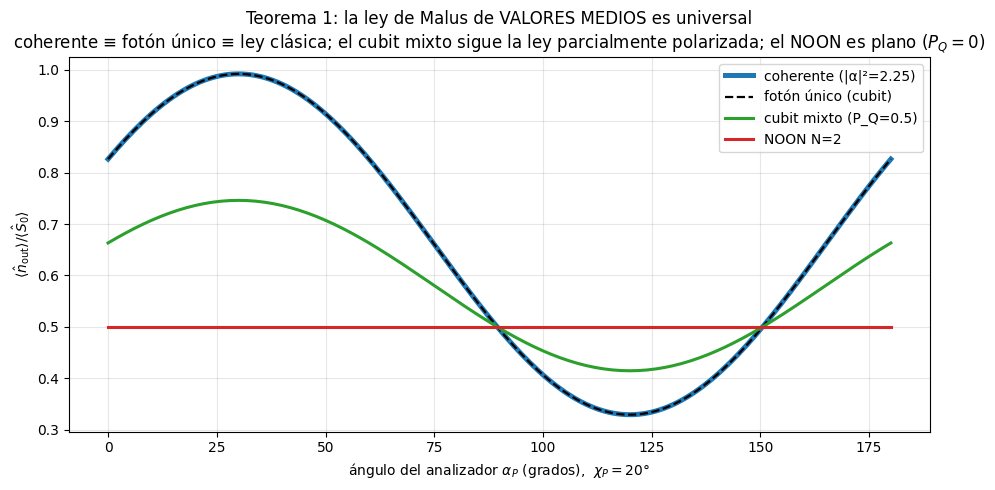


Coherente tras el polarizador: máx |p(k) − Poisson(|α|²·C12)| = 1.8720723314869998e-07


In [3]:
# ── 3. Estados de prueba y curvas de Malus de valores medios ─────────────
def vac():
    v = np.zeros(dim1**2, complex)
    v[0] = 1.0
    return v

def estado_coherente(amp, u):
    """|α;u⟩ = |α u_H⟩_H ⊗ |α u_V⟩_V (coherente en el modo de Jones u)."""
    def coh(z):
        n = np.arange(dim1)
        v = z**n / np.sqrt(np.array([float(factorial(k)) for k in n]))
        return np.exp(-abs(z)**2/2) * v.astype(complex)
    return np.kron(coh(amp*u[0]), coh(amp*u[1]))

def foton_unico(u):
    """|1_u⟩ = (u_H a†_H + u_V a†_V)|0⟩ — cubit de polarización."""
    return (u[0]*adH + u[1]*adV) @ vac()

def estado_noon2():
    """|NOON₂⟩ = (|2,0⟩+|0,2⟩)/√2 = (a†_H² + a†_V²)|0⟩/2."""
    return (adH@adH + adV@adV) @ vac() / 2.0

def base_bl(p, k, l):
    """|k⟩_b |l⟩_b⊥ = b†^k b⊥†^l |0⟩ / √(k! l!)."""
    bd  = p[0]*adH + p[1]*adV
    bpd = -p[1].conjugate()*adH + p[0].conjugate()*adV
    v = vac()
    for _ in range(k):
        v = bd @ v
    for _ in range(l):
        v = bpd @ v
    return v / np.sqrt(float(factorial(k))*float(factorial(l)))

def media_nout(rho_o_psi, alpha_P, chi_P):
    b, _, _ = modos_analizador(alpha_P, chi_P)
    nb = b.conj().T @ b
    if rho_o_psi.ndim == 1:
        return np.real(rho_o_psi.conj() @ nb @ rho_o_psi)
    return np.real(np.trace(rho_o_psi @ nb))

# Estados: mismo (α_in, χ_in) para todos los polarizados
alpha_in, chi_in = np.radians(30), np.radians(15)
u_in = jones(alpha_in, chi_in)
s_in = stokes_unit(alpha_in, chi_in)

amp = 1.5
psi_coh  = estado_coherente(amp, u_in)
psi_1f   = foton_unico(u_in)
psi_noon = estado_noon2()
# cubit mixto (fotón único parcialmente polarizado, P_Q = 0.5):
PQ = 0.5
rho_desp = 0.5*(np.outer(foton_unico(np.array([1, 0])), foton_unico(np.array([1, 0])).conj())
                + np.outer(foton_unico(np.array([0, 1])), foton_unico(np.array([0, 1])).conj()))
rho_mix = PQ*np.outer(psi_1f, psi_1f.conj()) + (1 - PQ)*rho_desp

# Barrido del analizador: α_P = θ, χ_P fija
chi_P0 = np.radians(20)
thetas = np.linspace(0, np.pi, 181)

def C12(phi, ci, cp):
    return 0.5*(1 + np.cos(2*ci)*np.cos(2*cp)*np.cos(2*phi)
                + np.sin(2*ci)*np.sin(2*cp))

curvas = {}
for nombre, st in [("coherente (|α|²=2.25)", psi_coh),
                   ("fotón único (cubit)", psi_1f),
                   ("cubit mixto (P_Q=0.5)", rho_mix),
                   ("NOON N=2", psi_noon)]:
    n_in = (np.real(st.conj() @ S0 @ st) if st.ndim == 1
            else np.real(np.trace(st @ S0)))
    curvas[nombre] = np.array([media_nout(st, th, chi_P0) for th in thetas]) / n_in

# Verificación contra el Teorema 1 / ley clásica parcialmente polarizada
teo_pura = C12(alpha_in - thetas, chi_in, chi_P0)
teo_mix  = 0.5*(1 + PQ*(np.cos(2*chi_in)*np.cos(2*chi_P0)*np.cos(2*(alpha_in - thetas))
                        + np.sin(2*chi_in)*np.sin(2*chi_P0)))
print("máx |coherente − C12|   =", np.abs(curvas["coherente (|α|²=2.25)"] - teo_pura).max())
print("máx |fotón único − C12| =", np.abs(curvas["fotón único (cubit)"] - teo_pura).max())
print("máx |cubit mixto − ley parcial| =", np.abs(curvas["cubit mixto (P_Q=0.5)"] - teo_mix).max())
print("máx |NOON − 1/2|        =", np.abs(curvas["NOON N=2"] - 0.5).max())

fig, ax = plt.subplots(figsize=(9.5, 5))
estilos = {"coherente (|α|²=2.25)": dict(color="C0", ls="-",  lw=3.6),
           "fotón único (cubit)":   dict(color="k",  ls="--", lw=1.6),
           "cubit mixto (P_Q=0.5)": dict(color="C2", ls="-",  lw=2.2),
           "NOON N=2":              dict(color="C3", ls="-",  lw=2.2)}
for nombre, c in curvas.items():
    ax.plot(np.degrees(thetas), c, label=nombre, **estilos[nombre])
ax.set_xlabel(r"ángulo del analizador $\alpha_P$ (grados),  $\chi_P=20°$")
ax.set_ylabel(r"$\langle \hat n_{\rm out}\rangle / \langle \hat S_0\rangle$")
ax.set_title("Teorema 1: la ley de Malus de VALORES MEDIOS es universal\n"
             "coherente ≡ fotón único ≡ ley clásica; el cubit mixto sigue la ley "
             "parcialmente polarizada; el NOON es plano ($P_Q=0$)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("malus_cuantica_medias.png", dpi=150, bbox_inches="tight")
plt.show()

# Estadística Poisson del coherente transmitido (χ_P, α_P de prueba)
aP_t, cP_t = np.radians(37.0), np.radians(-13.0)
p_t = jones(aP_t, cP_t)
eta = C12(alpha_in - aP_t, chi_in, cP_t)
media = amp**2 * eta
pk = np.zeros(NMAX + 1)
for k in range(NMAX + 1):
    for l in range(NMAX + 1 - k):
        ck = base_bl(p_t, k, l).conj() @ psi_coh
        pk[k] += abs(ck)**2
poisson = np.exp(-media)*media**np.arange(NMAX + 1)/np.array(
    [float(factorial(k)) for k in range(NMAX + 1)])
print("\nCoherente tras el polarizador: máx |p(k) − Poisson(|α|²·C12)| =",
      np.abs(pk - poisson).max())

máx |p₂(χ_P) − ½cos²2χ_P| = 2.7755575615628914e-16
variación de p(k) con α_P (debe ser 0): 3.885780586188048e-16
media ⟨n_out⟩ = p₁ + 2p₂ (debe ser 1): 6.661338147750939e-16


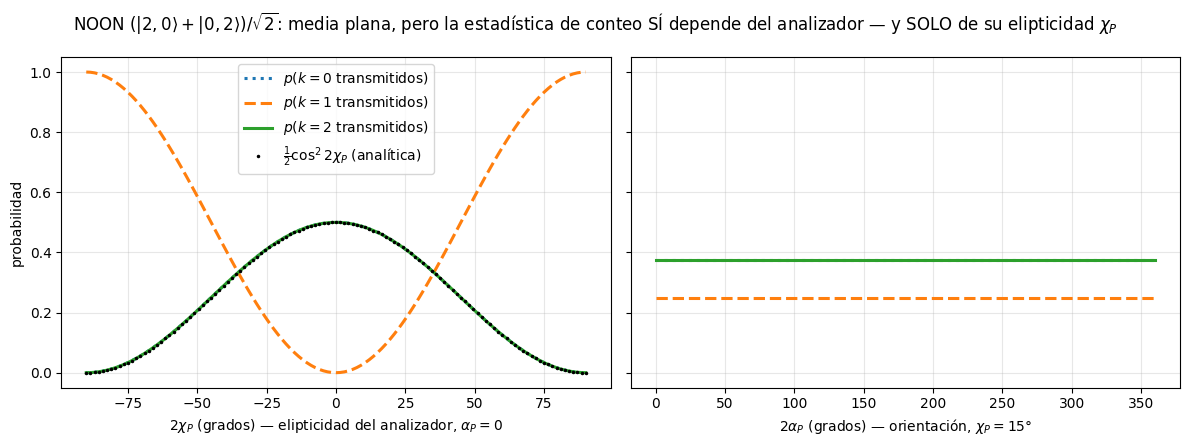

In [4]:
# ── 3.4 Polarización oculta: estadística del NOON tras el analizador ─────
def probs_kl(psi, alpha_P, chi_P, N):
    p = jones(alpha_P, chi_P)
    return np.array([abs(base_bl(p, k, N - k).conj() @ psi)**2
                     for k in range(N + 1)])

chis = np.linspace(-np.pi/4, np.pi/4, 121)
pk_chi = np.array([probs_kl(psi_noon, 0.0, c, 2) for c in chis])       # α_P = 0
alphas = np.linspace(0, np.pi, 121)
pk_alp = np.array([probs_kl(psi_noon, a, np.radians(15), 2) for a in alphas])

# Predicción analítica: p(2 pasan) = ½cos²(2χ_P), independiente de α_P
print("máx |p₂(χ_P) − ½cos²2χ_P| =",
      np.abs(pk_chi[:, 2] - 0.5*np.cos(2*chis)**2).max())
print("variación de p(k) con α_P (debe ser 0):", np.ptp(pk_alp, axis=0).max())
print("media ⟨n_out⟩ = p₁ + 2p₂ (debe ser 1):",
      np.abs(pk_chi[:, 1] + 2*pk_chi[:, 2] - 1).max())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for k, ls in [(0, ":"), (1, "--"), (2, "-")]:
    axes[0].plot(np.degrees(2*chis), pk_chi[:, k], ls, lw=2.2,
                 label=rf"$p(k={k}$ transmitidos$)$")
    axes[1].plot(np.degrees(2*alphas), pk_alp[:, k], ls, lw=2.2)
axes[0].plot(np.degrees(2*chis), 0.5*np.cos(2*chis)**2, "k.", ms=3,
             label=r"$\frac{1}{2}\cos^2 2\chi_P$ (analítica)")
axes[0].set_xlabel(r"$2\chi_P$ (grados) — elipticidad del analizador, $\alpha_P=0$")
axes[1].set_xlabel(r"$2\alpha_P$ (grados) — orientación, $\chi_P=15°$")
axes[0].set_ylabel("probabilidad")
axes[0].legend(fontsize=10)
fig.suptitle(r"NOON $(|2,0\rangle+|0,2\rangle)/\sqrt{2}$: media plana, pero la estadística"
             r" de conteo SÍ depende del analizador — y SOLO de su elipticidad $\chi_P$")
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("malus_cuantica_noon.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 4. Teorema 2 — Ley de Malus en el espacio de fases de dos modos (Wigner CV)

La **función de Wigner de dos modos** se define a partir de la función característica simétrica,
$$W(\alpha_H,\alpha_V)=\frac{1}{\pi^{4}}\int d^{2}\lambda_H\,d^{2}\lambda_V\;
e^{\sum_i(\lambda_i^{*}\alpha_i-\lambda_i\alpha_i^{*})}\;
\mathrm{Tr}\Big[\rho\,e^{\sum_i(\lambda_i\hat a_i^{\dagger}-\lambda_i^{*}\hat a_i)}\Big],$$
y su propiedad definitoria es que calcula promedios de operadores en **orden simétrico (Weyl)**:
$\langle\{\hat A\}_{\text{sym}}\rangle=\int d^{4}\alpha\;W(\alpha)\,A_{W}(\alpha)$, donde $A_W$ es el símbolo de Weyl.

**Símbolo de Weyl del contador.** Para operadores cuadráticos, la simetrización es elemental:
$\{\hat a_i^{\dagger}\hat a_j\}_{\text{sym}}=\hat a_i^{\dagger}\hat a_j+\tfrac12\delta_{ij}$, luego el símbolo de $\hat a_i^{\dagger}\hat a_j$ es $\alpha_i^{*}\alpha_j-\tfrac12\delta_{ij}$ y, para el modo transmitido $\beta_p(\alpha)=p_H^{*}\alpha_H+p_V^{*}\alpha_V$,

$$\big(\hat b^{\dagger}\hat b\big)_W=|\beta_p(\alpha)|^{2}-\tfrac12 .$$

**La ley clásica es una identidad puntual en el espacio de fases.** Definiendo los campos de Stokes clásicos $s_\mu(\alpha)=\boldsymbol{\alpha}^{\dagger}\sigma_\mu\boldsymbol{\alpha}$ (con $\boldsymbol{\alpha}=(\alpha_H,\alpha_V)^T$), la Parte I da, punto a punto,
$$|\beta_p(\alpha)|^{2}=\tfrac12\big(s_0(\alpha)+\vec s(\alpha)\cdot\hat p\big)\;\equiv\;I^{\text{Malus}}_{\text{clásica}}(\alpha;\alpha_P,\chi_P).$$

### Teorema 2

$$\boxed{\;\langle \hat n_{\text{out}}\rangle=\int d^{4}\alpha\;W(\alpha_H,\alpha_V)\;
I^{\text{Malus}}_{\text{clásica}}(\alpha;\alpha_P,\chi_P)\;-\;\frac12\;}$$

**La ley de Malus cuántica de medias es la ley clásica promediada sobre la cuasi-distribución de Wigner**, menos medio fotón de vacío del modo transmitido. Para un estado coherente, $W$ es una gaussiana positiva centrada en la amplitud clásica y se recupera la Parte I; para estados no clásicos $W$ toma valores negativos y esas regiones codifican las desviaciones estadísticas.

### Estadística completa

El Teorema 2 se extiende a toda la distribución $p(n)$ porque la óptica lineal actúa sobre $W$ como **transformación de puntos** (rotación simpléctica $\alpha\mapsto U\alpha$): la Wigner del modo transmitido es la marginal
$$W_b(\beta)=\int d^{2}\beta_{\perp}\;W\big(U^{-1}(\beta,\beta_{\perp})\big),$$
y con la fórmula de solapamiento $\mathrm{Tr}(\hat A\hat B)=\pi\int d^2\beta\,W_A W_B$:
$$p(n)=\pi\int d^{2}\beta\;W_b(\beta)\,W_{|n\rangle\langle n|}(\beta),\qquad
W_{|n\rangle\langle n|}(\beta)=\frac{2}{\pi}(-1)^{n}e^{-2|\beta|^{2}}L_n\big(4|\beta|^{2}\big).$$

Ésta es la **ley de Malus cuántica completa en variables continuas**: toda la estadística de conteo tras el polarizador elíptico está determinada por la geometría clásica del espacio de fases aplicada a $W$. Además, la **negatividad de $W_b$ certifica no-clasicidad de la luz transmitida** — y, como muestra la celda siguiente con el NOON, esa negatividad puede *encenderse y apagarse con la elipticidad del analizador*.

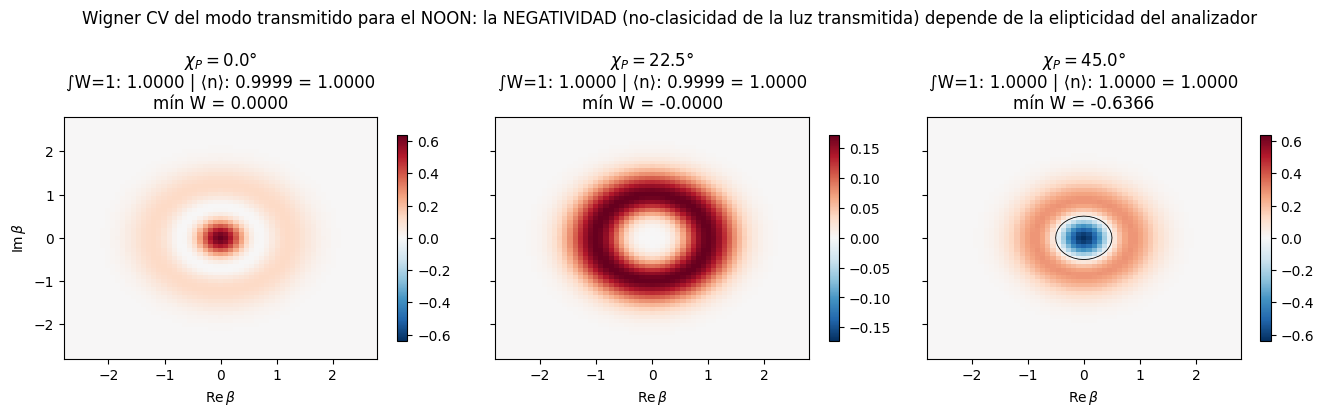

In [5]:
# ── 4. Función de Wigner CV del modo transmitido ─────────────────────────
def rho_modo_b(psi, alpha_P, chi_P, kmax):
    """Estado reducido del modo transmitido: ρ_b[k,k'] = Σ_l c_kl c*_k'l."""
    p = jones(alpha_P, chi_P)
    c = np.zeros((kmax + 1, kmax + 1), complex)
    for k in range(kmax + 1):
        for l in range(kmax + 1 - k):
            c[k, l] = base_bl(p, k, l).conj() @ psi
    return c @ c.conj().T

def wigner_1modo(rho, xvec, ndim=45):
    """W(β) = (2/π) Tr[D†(β) ρ D(β) (−1)^n]  (paridad desplazada).
    ndim debe ser holgado: el D(β) truncado genera artefactos para
    |β| grande (anillos espurios que arruinan ∫W dβ² = 1)."""
    a = np.diag(np.sqrt(np.arange(1, ndim)), 1)
    ad = a.conj().T
    par = np.diag((-1.0)**np.arange(ndim))
    rho_e = np.zeros((ndim, ndim), complex)
    d = rho.shape[0]
    rho_e[:d, :d] = rho
    W = np.zeros((len(xvec), len(xvec)))
    for i, x in enumerate(xvec):
        for j, y in enumerate(xvec):
            beta = x + 1j*y
            D = expm(beta*ad - beta.conjugate()*a)
            W[j, i] = (2/np.pi)*np.real(np.trace(D.conj().T @ rho_e @ D @ par))
    return W

xvec = np.linspace(-2.75, 2.75, 61)
dx = xvec[1] - xvec[0]
X, Y = np.meshgrid(xvec, xvec)
R2 = X**2 + Y**2

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharey=True)
for ax, cPv in zip(axes, [0.0, np.pi/8, np.pi/4]):
    rb = rho_modo_b(psi_noon, 0.0, cPv, 4)
    W = wigner_1modo(rb, xvec)
    vmax = np.abs(W).max()
    im = ax.pcolormesh(X, Y, W, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.contour(X, Y, W, levels=[0], colors="k", linewidths=0.6)
    plt.colorbar(im, ax=ax, shrink=0.85)
    # Verificaciones: normalización, media (Teorema 2, con el −1/2 del vacío)
    norma = W.sum()*dx**2
    n_media_W = (W*(R2 - 0.5)).sum()*dx**2
    n_media_rho = np.real(np.trace(rb @ np.diag(np.arange(5))))
    ax.set_title(rf"$\chi_P = {np.degrees(cPv):.1f}°$"
                 f"\n∫W=1: {norma:.4f} | ⟨n⟩: {n_media_W:.4f} = {n_media_rho:.4f}"
                 f"\nmín W = {W.min():.4f}")
    ax.set_xlabel(r"$\mathrm{Re}\,\beta$")
axes[0].set_ylabel(r"$\mathrm{Im}\,\beta$")
fig.suptitle("Wigner CV del modo transmitido para el NOON: la NEGATIVIDAD "
             "(no-clasicidad de la luz transmitida) depende de la elipticidad del analizador")
plt.tight_layout()
plt.savefig("malus_cuantica_wigner_cv.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Teorema 3 — La ley de Malus como solapamiento de Wigner **en la esfera de Poincaré**

La formulación CV es completa pero vive en 4 dimensiones. La formulación natural para polarización usa que el problema tiene simetría SU(2): construimos la función de Wigner **sobre la propia esfera de Poincaré** (Stratonovich 1956; Agarwal 1981).

### 5.1 Sectores de número y espín

$[\hat S_0,\hat{\vec S}]=0$: los operadores de Stokes actúan dentro de cada sector de $N$ fotones. Por la aplicación de Schwinger, el sector $N$ es un espín $j=N/2$ con base $|j,m\rangle=|n_H=j+m,\;n_V=j-m\rangle$ y $\hat{\vec J}=\hat{\vec S}/2$. Crucial: **la medición completa del polarizador (contar $k$ transmitidos y $l$ rechazados) conserva $N=k+l$**, así que las coherencias entre sectores no contribuyen a la estadística:
$$p(k,l)=\mathrm{Tr}\big[\hat P_N\,\rho\,\hat P_N\;\Pi_k^{(N)}\big],\qquad N=k+l,$$
y basta formular la ley sector por sector. Los elementos POVM son proyectores de Dicke rotados,
$$\Pi_k^{(N)}=|k\rangle_b|N-k\rangle_{b_\perp}\!\langle\cdots|
\;=\;\text{autoproyector de }\hat p\cdot\hat{\vec J}\text{ con autovalor }m=k-\tfrac N2,$$
donde usamos la identidad del Teorema 1 y su compañera: $\hat p\cdot\hat{\vec S}=\hat b^{\dagger}\hat b-\hat b_{\perp}^{\dagger}\hat b_{\perp}$.

### 5.2 El núcleo de Stratonovich–Weyl

Con los operadores tensoriales irreducibles $\hat T_{LM}$ del espín $j$ (ortonormales, $\mathrm{Tr}[\hat T^{\dagger}_{LM}\hat T_{L'M'}]=\delta_{LL'}\delta_{MM'}$, con elementos $\langle jm'|\hat T_{LM}|jm\rangle=\sqrt{\tfrac{2L+1}{2j+1}}\,\langle jm;LM|jm'\rangle$), el núcleo es

$$\hat\Delta(\Omega)=\sqrt{\frac{4\pi}{2j+1}}\sum_{L=0}^{2j}\sum_{M=-L}^{L}Y^{*}_{LM}(\Omega)\,\hat T_{LM},
\qquad W_A(\Omega)=\mathrm{Tr}\big[\hat A\,\hat\Delta(\Omega)\big].$$

Satisface los axiomas de Stratonovich–Weyl, verificados numéricamente abajo: (i) hermiticidad ($W_A$ real para $\hat A$ hermítico); (ii) normalización, $W_{\mathbb 1}=1$ y $\tfrac{2j+1}{4\pi}\int W_\rho\,d\Omega=1$; (iii) **tracialidad**: $\mathrm{Tr}[\hat A\hat B]=\tfrac{2j+1}{4\pi}\int_{S^2} W_A W_B\,d\Omega$; (iv) covariancia bajo rotaciones SU(2) (= rotaciones rígidas de la esfera de Poincaré); (v) reconstrucción $\hat A=\tfrac{2j+1}{4\pi}\int W_A(\Omega)\hat\Delta(\Omega)d\Omega$.

*Detalle de coordenadas*: la base $|j,m\rangle$ es la de Fock $H/V$, así que el eje de cuantización del espín es el eje $S_1$ de Poincaré; el diccionario es $(J_x,J_y,J_z)\leftrightarrow(S_2,S_3,S_1)/2$ (triada dextrógira, pues $[\hat S_2,\hat S_3]=2i\hat S_1$).

### 5.3 Teorema 3 (ley de Malus cuántica en la esfera de Poincaré)

Aplicando la tracialidad a $\rho_N$ y $\Pi_k$:

$$\boxed{\;p(k\ \text{transmitidos}\mid\alpha_P,\chi_P)
=\frac{2j+1}{4\pi}\int_{S^{2}}d\Omega\;W_{\rho_N}(\Omega)\;W_{\Pi_k}(\Omega)\;}\qquad j=\frac{N}{2}$$

con dos propiedades estructurales que la hacen "verdaderamente elíptica":

- **Zonalidad del analizador**: $\Pi_k$ es un proyector de Dicke rotado hacia $\hat p$, así que $W_{\Pi_k}(\Omega)$ depende de $\Omega$ **sólo a través de la distancia angular** $\Theta$ al punto de Poincaré del analizador ($\cos\Theta=\hat n\cdot\hat p$): $W_{\Pi_k}=\sum_{L\le 2j}c^{(j,k)}_L P_L(\cos\Theta)$. Toda la ley es geometría rotacionalmente covariante sobre la esfera; el polarizador elíptico entra únicamente por su punto $\hat p(\alpha_P,\chi_P)$.
- **Jerarquía de leyes**: la media $\sum_k k\,p(k)$ reproduce el Teorema 1; el sector $N=1$ da la regla de Born; la mezcla Poissoniana de sectores da el estado coherente y su límite clásico $j\to\infty$, donde $W_{\rho}$ se localiza en un punto $\hat s$ y la ley se vuelve determinista.

### 5.4 El caso $j=1/2$: la ley generalizada de la Parte I, reobtenida

Para $j=\tfrac12$ el núcleo tiene forma cerrada $\hat\Delta(\Omega)=\tfrac12\big(\mathbb 1+\sqrt3\,\hat n\cdot\vec\sigma\big)$, luego
$$W_\varrho(\Omega)=\tfrac12\big(1+\sqrt3\,\hat n\cdot\vec r\big),\qquad
W_{\Pi}(\Omega)=\tfrac12\big(1+\sqrt3\,\hat n\cdot\hat p\big),$$
y usando $\int \hat n\,d\Omega=0$, $\int n_i n_j\,d\Omega=\tfrac{4\pi}{3}\delta_{ij}$:
$$p_{\text{trans}}=\frac{2}{4\pi}\int W_\varrho W_\Pi\,d\Omega=\frac12\big(1+\vec r\cdot\hat p\big).$$
Con $\vec r=P_Q\,\hat s_{\text{in}}$ esto es **exactamente** la ley de la Parte II (y la Parte I si $P_Q=1$): la ley de Malus generalizada *es* un solapamiento de funciones de Wigner sobre la esfera de Poincaré.

> **Precaución conceptual.** La Wigner SU(2) de *todo* estado puro de espín bajo tiene regiones negativas (mínimo $\tfrac{1-\sqrt3}{2}$ para el cubit): a $j$ pequeño la negatividad de $W$ **no** es un certificado de no-clasicidad — para eso se usa la función $P$ de SU(2) o, en CV, la negatividad de $W_b$ (§4). Lo exacto e incondicional aquí es la **ley** (Teorema 3), no una lectura ingenua de los signos.

In [6]:
# ── 5. Núcleo de Stratonovich–Weyl para SU(2) ────────────────────────────
from sympy.physics.quantum.cg import CG
from scipy.special import lpmv

def esf_armonico(L, M, theta, phi):
    """Y_LM(θ,φ) con fase de Condon–Shortley (lpmv ya la incluye)."""
    Ma = abs(M)
    norm = np.sqrt((2*L + 1)/(4*np.pi)*factorial(L - Ma)/factorial(L + Ma))
    Yp = norm*lpmv(Ma, L, np.cos(theta))*np.exp(1j*Ma*np.asarray(phi))
    return (-1.0)**Ma*np.conj(Yp) if M < 0 else Yp

def ops_espin(j):
    """Matrices de espín j en la base |j,m⟩, m = −j…+j."""
    dim = int(round(2*j)) + 1
    ms = np.arange(dim) - j
    Jz = np.diag(ms)
    Jp = np.zeros((dim, dim))
    for i in range(dim - 1):
        Jp[i + 1, i] = np.sqrt(j*(j + 1) - ms[i]*(ms[i] + 1))
    Jx = (Jp + Jp.T)/2
    Jy = (Jp - Jp.T)/2j
    return Jx, Jy, Jz

def tensores_irreducibles(j):
    """T̂_LM con ⟨jm'|T̂_LM|jm⟩ = √((2L+1)/(2j+1)) ⟨j m; L M|j m'⟩,
    ortonormales: Tr[T̂†_LM T̂_L'M'] = δ_LL' δ_MM'."""
    dim = int(round(2*j)) + 1
    j_s = sp.Rational(int(round(2*j)), 2)
    T = {}
    for L in range(dim):
        for M in range(-L, L + 1):
            mat = np.zeros((dim, dim), complex)
            for im, in_m in enumerate(np.arange(dim) - j):
                imp = im + M
                if 0 <= imp < dim:
                    m_s = sp.Rational(int(round(2*in_m)), 2)
                    mp_s = m_s + M
                    cg = float(CG(j_s, m_s, L, M, j_s, mp_s).doit())
                    mat[imp, im] = np.sqrt((2*L + 1)/(2*j + 1))*cg
            T[(L, M)] = mat
    return T

def nucleo_SW(j, T, theta, phi):
    """Δ̂(Ω) = √(4π/(2j+1)) Σ_LM Y*_LM(Ω) T̂_LM."""
    dim = int(round(2*j)) + 1
    D = np.zeros((dim, dim), complex)
    for (L, M), mat in T.items():
        D += np.conj(esf_armonico(L, M, theta, phi))*mat
    return np.sqrt(4*np.pi/(2*j + 1))*D

# Malla de integración: Gauss–Legendre en cosθ × uniforme en φ (exacta
# para armónicos de grado ≤ 2·40−1)
NGL, NPHI = 40, 81
xg, wg = np.polynomial.legendre.leggauss(NGL)
thetag = np.arccos(xg)
phig = np.linspace(0, 2*np.pi, NPHI, endpoint=False)
TH, PH = np.meshgrid(thetag, phig, indexing="ij")
Wq = np.outer(wg, np.full(NPHI, 2*np.pi/NPHI))     # pesos dΩ

def simbolo_W(A, kernels):
    return np.real(np.einsum("ij,tpji->tp", A, kernels))

def prueba_axiomas(j):
    T = tensores_irreducibles(j)
    dim = int(round(2*j)) + 1
    kern = np.zeros((NGL, NPHI, dim, dim), complex)
    for it in range(NGL):
        for ip in range(NPHI):
            kern[it, ip] = nucleo_SW(j, T, thetag[it], phig[ip])
    herm = max(np.abs(kern[it, ip] - kern[it, ip].conj().T).max()
               for it in range(0, NGL, 7) for ip in range(0, NPHI, 13))
    W_id = simbolo_W(np.eye(dim), kern)
    rng2 = np.random.default_rng(3)
    errs = []
    for _ in range(6):
        A = rng2.normal(size=(dim, dim)) + 1j*rng2.normal(size=(dim, dim))
        A = A + A.conj().T
        B = rng2.normal(size=(dim, dim)) + 1j*rng2.normal(size=(dim, dim))
        B = B + B.conj().T
        ovl = (2*j + 1)/(4*np.pi)*np.sum(Wq*simbolo_W(A, kern)*simbolo_W(B, kern))
        errs.append(abs(ovl - np.real(np.trace(A@B))))
    # reconstrucción: Â = (2j+1)/(4π) ∫ W_A(Ω) Δ̂(Ω) dΩ
    A_rec = (2*j + 1)/(4*np.pi)*np.einsum(
        "tp,tp,tpij->ij", Wq, simbolo_W(A, kern), kern)
    print(f"j = {j}:  hermiticidad {herm:.1e} | máx|W_𝟙−1| {np.abs(W_id-1).max():.1e}"
          f" | Tr[AB] vs ∫W_AW_B {max(errs):.1e}"
          f" | reconstrucción {np.abs(A_rec - A).max():.1e}")
    return T, kern

T_half, kern_half = prueba_axiomas(0.5)
T_one,  kern_one  = prueba_axiomas(1.0)

j = 0.5:  hermiticidad 0.0e+00 | máx|W_𝟙−1| 2.2e-16 | Tr[AB] vs ∫W_AW_B 2.1e-14 | reconstrucción 1.2e-14
j = 1.0:  hermiticidad 0.0e+00 | máx|W_𝟙−1| 2.2e-16 | Tr[AB] vs ∫W_AW_B 2.5e-14 | reconstrucción 3.6e-15


In [7]:
# ── 5b. j = 1/2: la ley de Malus generalizada como solapamiento de Wigner ─
# Forma cerrada del núcleo: Δ̂(Ω) = ½(𝟙 + √3 n̂·σ⃗)
Jx, Jy, Jz = ops_espin(0.5)
err_forma = 0.0
for it in range(0, NGL, 5):
    for ip in range(0, NPHI, 9):
        n = np.array([np.sin(thetag[it])*np.cos(phig[ip]),
                      np.sin(thetag[it])*np.sin(phig[ip]),
                      np.cos(thetag[it])])
        cerr = 0.5*np.eye(2) + np.sqrt(3)*(n[0]*Jx + n[1]*Jy + n[2]*Jz)
        err_forma = max(err_forma, np.abs(kern_half[it, ip] - cerr).max())
print("máx ‖Δ̂ − ½(𝟙+√3 n̂·σ⃗)‖ =", f"{err_forma:.2e}")

# Diccionario Poincaré ↔ espín: (S1,S2,S3) = 2(Jz,Jx,Jy)
# (la base |j,m⟩ es la de Fock H/V: el eje de cuantización es S1)
def vec_espin(s):          # vector de Stokes → marco del espín (x,y,z)
    return np.array([s[1], s[2], s[0]])

def proyector_k(j, alpha_P, chi_P, k):
    """Π̂_k = |k⟩_b|N−k⟩_b⊥⟨…| como autoproyector de p̂·J⃗ (autovalor k−j)."""
    Jx_, Jy_, Jz_ = ops_espin(j)
    n = vec_espin(stokes_unit(alpha_P, chi_P))
    val, vec = np.linalg.eigh(n[0]*Jx_ + n[1]*Jy_ + n[2]*Jz_)
    idx = np.argmin(np.abs(val - (k - j)))
    v = vec[:, idx]
    return np.outer(v, v.conj())

# fotón único (N=1, j=1/2): base m=(−1/2,+1/2) ↔ (|0,1⟩,|1,0⟩) = (V,H)
psi_q = np.array([u_in[1], u_in[0]])
rho_q = np.outer(psi_q, psi_q.conj())
r_bloch = np.array([np.real(np.trace(rho_q @ (2*M)))
                    for M in (Jz, Jx, Jy)])           # (S1,S2,S3)
print("r⃗ del cubit − ŝ(α_in,χ_in) =", np.abs(r_bloch - s_in).max())

errs = []
for th in thetas[::6]:
    Pi = proyector_k(0.5, th, chi_P0, k=1)            # transmite el fotón
    p_dir = np.real(np.trace(rho_q @ Pi))
    p_wig = 2/(4*np.pi)*np.sum(Wq*simbolo_W(rho_q, kern_half)
                               * simbolo_W(Pi, kern_half))
    errs.append([abs(p_dir - C12(alpha_in - th, chi_in, chi_P0)),
                 abs(p_wig - p_dir)])
errs = np.array(errs)
print("máx |Tr(ρΠ) − C12|            =", f"{errs[:,0].max():.2e}")
print("máx |solape Wigner − Tr(ρΠ)|  =", f"{errs[:,1].max():.2e}")
print("✓ Ley de Malus generalizada = solapamiento de funciones de Wigner SU(2)")

máx ‖Δ̂ − ½(𝟙+√3 n̂·σ⃗)‖ = 3.14e-16
r⃗ del cubit − ŝ(α_in,χ_in) = 5.551115123125783e-17
máx |Tr(ρΠ) − C12|            = 4.44e-16
máx |solape Wigner − Tr(ρΠ)|  = 8.88e-16
✓ Ley de Malus generalizada = solapamiento de funciones de Wigner SU(2)


### 5.5 El sector $N=2$ y el NOON: verificación completa del Teorema 3

Para $j=1$ verificamos el Teorema 3 contra (a) el cálculo directo con proyectores y (b) el cálculo independiente en el espacio de Fock de dos modos de §3. El mapa de $W_{\rho}$ del NOON sobre la esfera de Poincaré hace *visible* la polarización oculta: el estado es un **anillo ecuatorial con negatividad en los polos $S_3$** — estructura puramente latitudinal (invariante en $2\alpha$), que sólo un analizador con $\chi_P\neq 0$ puede sondear, en perfecto acuerdo con $p(2)=\tfrac12\cos^2 2\chi_P$.

máx |p(k) espín − p(k) Fock dos modos| = 1.22e-15
máx |solape Wigner (Teorema 3) − directo| = 1.60e-15


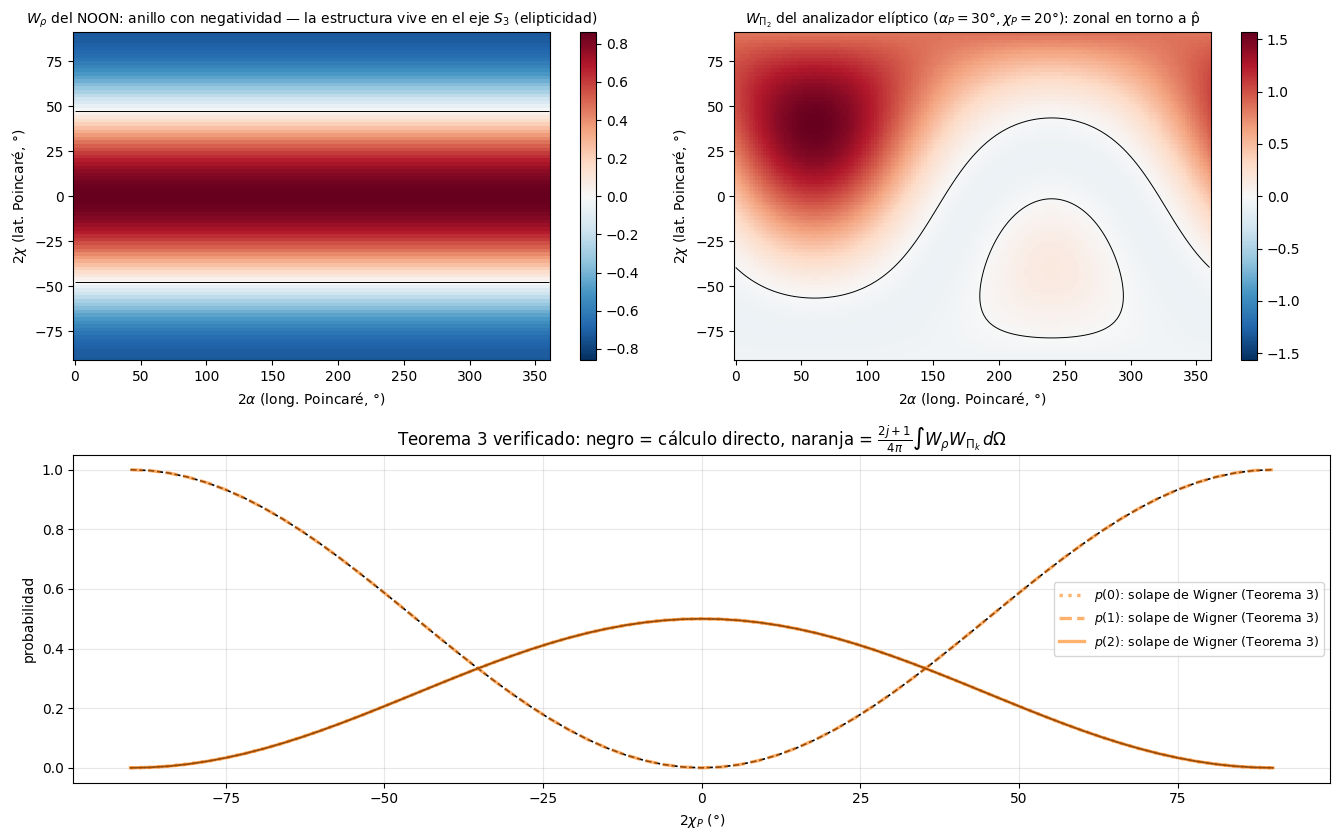

In [8]:
# ── 5c. N = 2 (j = 1): Teorema 3 para el estado NOON ─────────────────────
# base m = (−1, 0, +1) ↔ (|0,2⟩, |1,1⟩, |2,0⟩)
psi_noon_j1 = np.array([1, 0, 1])/np.sqrt(2)
rho_noon_j1 = np.outer(psi_noon_j1, psi_noon_j1.conj())

# Verificación del Teorema 3 contra el cálculo directo en el espacio de Fock
err_T3, err_fock = 0.0, 0.0
for cPv in np.linspace(-np.pi/4, np.pi/4, 31):
    for aPv in [0.0, np.radians(30), np.radians(75)]:
        pk_fock = probs_kl(psi_noon, aPv, cPv, 2)
        for k in range(3):
            Pi = proyector_k(1.0, aPv, cPv, k)
            p_dir = np.real(np.trace(rho_noon_j1 @ Pi))
            p_wig = 3/(4*np.pi)*np.sum(Wq*simbolo_W(rho_noon_j1, kern_one)
                                       * simbolo_W(Pi, kern_one))
            err_T3 = max(err_T3, abs(p_wig - p_dir))
            err_fock = max(err_fock, abs(p_dir - pk_fock[k]))
print("máx |p(k) espín − p(k) Fock dos modos| =", f"{err_fock:.2e}")
print("máx |solape Wigner (Teorema 3) − directo| =", f"{err_T3:.2e}")

# Mapas de Wigner sobre la esfera de Poincaré (coordenadas 2α, 2χ)
n2a, n2c = 181, 91
a_grid = np.linspace(0, 2*np.pi, n2a)        # 2α
c_grid = np.linspace(-np.pi/2, np.pi/2, n2c) # 2χ
AG, CG_ = np.meshgrid(a_grid, c_grid)
# punto de Poincaré → ángulos del marco de espín (z = S1)
nx = np.cos(CG_)*np.sin(AG)   # S2
ny = np.sin(CG_)              # S3
nz = np.cos(CG_)*np.cos(AG)   # S1
TH_P = np.arccos(np.clip(nz, -1, 1))
PH_P = np.arctan2(ny, nx)

def W_mapa(A, j, T):
    dim = int(round(2*j)) + 1
    out = np.zeros_like(TH_P)
    D = np.zeros((dim, dim), complex)
    for i in range(TH_P.shape[0]):
        for jj in range(TH_P.shape[1]):
            D = nucleo_SW(j, T, TH_P[i, jj], PH_P[i, jj])
            out[i, jj] = np.real(np.trace(A @ D))
    return out

aP_f, cP_f = np.radians(30), np.radians(20)
Pi2 = proyector_k(1.0, aP_f, cP_f, k=2)
W_noon = W_mapa(rho_noon_j1, 1.0, T_one)
W_Pi2 = W_mapa(Pi2, 1.0, T_one)

fig = plt.figure(figsize=(13.5, 8.5))
for i, (W, tt) in enumerate([
        (W_noon, r"$W_\rho$ del NOON: anillo con negatividad — la estructura vive"
                 " en el eje $S_3$ (elipticidad)"),
        (W_Pi2, r"$W_{\Pi_2}$ del analizador elíptico $(\alpha_P=30°,\chi_P=20°)$:"
                " zonal en torno a p̂")]):
    ax = fig.add_subplot(2, 2, i + 1)
    vmax = np.abs(W).max()
    im = ax.pcolormesh(np.degrees(AG), np.degrees(CG_), W,
                       cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.contour(np.degrees(AG), np.degrees(CG_), W, levels=[0],
               colors="k", linewidths=0.7)
    plt.colorbar(im, ax=ax)
    ax.set_xlabel(r"$2\alpha$ (long. Poincaré, °)")
    ax.set_ylabel(r"$2\chi$ (lat. Poincaré, °)")
    ax.set_title(tt, fontsize=10)
if True:
    ax = fig.add_subplot(2, 1, 2)
    chis_f = np.linspace(-np.pi/4, np.pi/4, 61)
    for k, ls in [(0, ":"), (1, "--"), (2, "-")]:
        p_dirs = [np.real(np.trace(rho_noon_j1 @ proyector_k(1.0, 0.0, c, k)))
                  for c in chis_f]
        p_wigs = [3/(4*np.pi)*np.sum(
            Wq*simbolo_W(rho_noon_j1, kern_one)
            * simbolo_W(proyector_k(1.0, 0.0, c, k), kern_one)) for c in chis_f]
        ax.plot(np.degrees(2*chis_f), p_dirs, "k" + ls, lw=1.2)
        ax.plot(np.degrees(2*chis_f), p_wigs, "C1" + ls, lw=2.4, alpha=0.6,
                label=rf"$p({k})$: solape de Wigner (Teorema 3)")
    ax.set_xlabel(r"$2\chi_P$ (°)")
    ax.set_ylabel("probabilidad")
    ax.set_title("Teorema 3 verificado: negro = cálculo directo, naranja = "
                 r"$\frac{2j+1}{4\pi}\int W_\rho W_{\Pi_k}\,d\Omega$")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("malus_cuantica_wigner_su2.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Conclusiones

**1. Verificación de la deducción clásica.** La ley de la Parte I, $C_{12}=\tfrac12[1+\cos2\chi_{\text{in}}\cos2\chi_P\cos2\phi+\sin2\chi_{\text{in}}\sin2\chi_P]$, es correcta y coincide con la regla de Born $|\langle p|\psi\rangle|^2$; su extensión a luz parcialmente polarizada es $I=\tfrac{S_0}{2}(1+P\,\hat s\cdot\hat p)$ (Parte II de `Malus_Generalizada.ipynb`).

**2. ¿"Sólo para cubits de estados coherentes"? No.**
- El cubit de polarización es el sector de **un fotón**, no un estado coherente; allí la ley es la **regla de Born** exacta para cualquier estado del cubit (puro o mixto).
- Para **estados coherentes** la ley aparece como ley de intensidades medias con estadística Poissoniana — el límite clásico exacto.
- Por el **Teorema 1**, la ley de valores medios vale para **todo** estado. Lo que es privativo de coherentes/fotón único es la *interpretación completa* (intensidad determinista / probabilidad de un cubit); en general la media no agota la física (polarización oculta, §3.4).

**3. La ley de Malus cuántica verdaderamente elíptica, para cualquier estado.** Es una jerarquía cerrada, y la función de Wigner —como se conjeturaba— es el vehículo correcto:

| Nivel | Enunciado | Válida para |
|---|---|---|
| Medias | $\langle\hat n_{\text{out}}\rangle=\tfrac12(\langle\hat S_0\rangle+\hat p\cdot\langle\hat{\vec S}\rangle)$ | todo estado |
| Espacio de fases CV | $\langle\hat n_{\text{out}}\rangle=\int W\,I^{\text{Malus}}_{\text{cl}}\,d^4\alpha-\tfrac12$; $\;p(n)=\pi\int W_b W_{|n\rangle}$ | todo estado |
| Esfera de Poincaré | $p(k)=\tfrac{2j+1}{4\pi}\int W_{\rho_N}W_{\Pi_k}\,d\Omega$, sector a sector | todo estado |

El contenido físico: **el polarizador elíptico actúa clásicamente** (geometría del punto $\hat p$ en la esfera de Poincaré / rotación de puntos en el espacio de fases); **toda la cuanticidad del experimento de Malus vive en la cuasi-distribución del estado**. Clásico vs. cuántico queda delimitado por la función $P$: si el estado es mezcla de coherentes ($P\ge0$), toda su estadística de Malus la reproduce un campo estocástico clásico; si no (fotón único, NOON), aparecen firmas imposibles clásicamente, como $p(2)=\tfrac12\cos^{2}2\chi_P$ con media plana.

**4. Propuesta experimental para este laboratorio.** El montaje de `malus_conteo_fotones.py` mide $\langle\hat n_{\text{out}}\rangle$; por el Teorema 1 *nunca* verá diferencias entre estados con el mismo $\langle\hat{\vec S}\rangle$. Para acceder al nivel cuántico de la ley se necesita la estadística: (i) medir $g^{(2)}$ o coincidencias tras el polarizador elíptico (dos SPCM y un divisor 50/50), y (ii) barrer $\chi_P$ — no sólo $\alpha_P$ — buscando modulaciones de las coincidencias con media plana: la firma de polarización oculta. El esquema QWP–PL–QWP de la Parte I ya proporciona el analizador elíptico necesario.

---
### Referencias

- R. L. Stratonovich, *Sov. Phys. JETP* **31**, 1012 (1956) — función de Wigner sobre grupos.
- G. S. Agarwal, *Phys. Rev. A* **24**, 2889 (1981) — representación de estados de espín en la esfera.
- J. P. Dowling, G. S. Agarwal, W. P. Schleich, *Phys. Rev. A* **49**, 4101 (1994) — Wigner atómica/SU(2).
- D. N. Klyshko, *Phys. Lett. A* **163**, 349 (1992) — polarización oculta.
- A. Luis, *Phys. Rev. A* **66**, 013806 (2002) — distribuciones de polarización en la esfera de Poincaré.
- G. Björk *et al.*, *Phys. Rev. A* **90**, 013830 (2014) — estados no polarizados a primer orden y estructura de polarización de orden superior.
- L. Mandel, E. Wolf, *Optical Coherence and Quantum Optics*, CUP (1995), caps. 6, 10, 12.
- R. M. A. Azzam, N. M. Bashara, *Ellipsometry and Polarized Light*, North-Holland (1987) — convenciones de Jones/Stokes.